# **Algoritmo de Schnorr de Factorización mediante QAOA a través de Qiskit (1)**

Este notebook va a ser una primera aproximación para explicar el procedimiento utilizado por Schnorr en sus papers:
- [Schnorr factoring via Diophantine Approximation](https://link.springer.com/chapter/10.1007/3-540-46416-6_24#preview).
- [Schnorr fast factoring by SVP, corrected](https://eprint.iacr.org/2021/933.pdf)
- [Yan et al.](https://arxiv.org/pdf/2212.12372)
- [BenBen Priestley](https://arxiv.org/abs/2503.08403)
- [L.S.Cano, G.B.Juan, G.C. de las Heras, A.B. García. "Factoring integers via Schnorr' algorithm assisted with VQE"](https://arxiv.org/abs/2411.16632)

## **0. Estructura del TFG.**
- Título: Simulación de algoritmos variacionales cuántico-clásicos (QAOA y VQE) aplicados a problemas de retículos (CVP y SVP).
- Objetivo: comparar dos enfoques cuántico-clásicos ejecutables en CPU.
- Parte 1: CVP con QAOA de ángulos fijos en Python (BenPrie/qaoa-for-cvp).
- Parte 2: SVP con VQE/QAOA simulados mediante LattiQ en C++ (Milos9304/LattiQ).

Ambos transforman el problema en un modelo Ising/QUBO.
- Introducción: relevancia de CVP y SVP en criptografía post-cuántica.
- Marco teórico: bases de QAOA, VQE y formulaciones Ising.
- Implementación: descripción, parámetros y ejecución en CPU.
- Resultados: comparación de energía, tiempo y precisión.
- Discusión: QAOA fijo → rápido pero aproximado; LattiQ → más exacto pero lento.
- Conclusiones: ambos son viables, educativos y reproducibles sin QPU.
- Trabajo futuro: añadir ruido, escalar qubits y explorar otras formulaciones.

In [1132]:
# Realizo los imports
import numpy as np
from copy import deepcopy
import sympy
from scipy.optimize import minimize


# Time keeping.
import time

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

Aqui establecemos una pequeña lista de los primeros numeros primos

In [1133]:
primes = [2,3,5,7,11,13,17,19,23,29,31,37,41,43,47,53,59,61,67,71,73,79,83,89,97,101,103,107,109,113,127,131,137,139,149,151,157,163,167,173,179,181,191,193,197,199,211,223,227,229,233,239,241,251,257,263,269,271,277,281,283,293,307,311,313,317,331,337,347,349,353,359,367,373,379,383,389,397,401,409,419,421,431,433,439,443,449,457,461,463,467,479,487,491,499,503,509,521,523,541,547,557,563,569,571,577,587,593,599,601,607,613,617,619,631,641,643,647,653,659,661,673,677,683,691,701,709,719,727,733,739,743,751,757,761,769,773,787,797,809,811,821,823,827,829,839,853,857,859,863,877,881,883,887,907,911,919,929,937,941,947,953,967,971,977,983,991,997,1009,1013,1019,1021,1031,1033,1039,1049,1051,1061,1063,1069,1087,1091,1093,1097,1103,1109,1117,1123,1129,1151,1153,1163,1171,1181,1187,1193,1201,1213,1217,1223,1229,1231,1237,1249,1259,1277,1279,1283,1289,1291,1297,1301,1303,1307,1319,1321,1327,1361,1367,1373,1381,1399,1409,1423,1427,1429,1433,1439,1447,1451,1453,1459,1471,1481,1483,1487,1489,1493,1499,1511,1523,1531,1543,1549,1553,1559,1567,1571,1579,1583,1597,1601,1607,1609,1613,1619,1621,1627,1637,1657,1663,1667,1669,1693,1697,1699,1709,1721,1723,1733,1741,1747,1753,1759,1777,1783,1787,1789,1801,1811,1823,1831,1847,1861,1867,1871,1873,1877,1879,1889,1901,1907,1913,1931,1933,1949,1951,1973,1979,1987,1993,1997,1999,2003,2011,2017,2027,2029,2039,2053,2063,2069,2081,2083,2087,2089,2099,2111,2113,2129,2131,2137,2141,2143,2153,2161,2179,2203,2207,2213,2221,2237,2239,2243,2251,2267,2269,2273,2281,2287,2293,2297,2309,2311,2333,2339,2341,2347,2351,2357,2371,2377,2381,2383,2389,2393,2399,2411,2417,2423,2437,2441,2447,2459,2467,2473,2477,2503,2521,2531,2539,2543,2549,2551,2557,2579,2591,2593,2609,2617,2621,2633,2647,2657,2659,2663,2671,2677,2683,2687,2689,2693,2699,2707,2711,2713,2719,2729,2731,2741,2749,2753,2767,2777,2789,2791,2797,2801,2803,2819,2833,2837,2843,2851,2857,2861,2879,2887,2897,2903,2909,2917,2927,2939,2953,2957,2963,2969,2971,2999,3001,3011,3019,3023,3037,3041,3049,3061,3067,3079,3083,3089,3109,3119,3121,3137,3163,3167,3169,3181,3187,3191,3203,3209,3217,3221,3229,3251,3253,3257,3259,3271,3299,3301,3307,3313,3319,3323,3329,3331,3343,3347,3359,3361,3371,3373,3389,3391,3407,3413,3433,3449,3457,3461,3463,3467,3469,3491,3499,3511,3517,3527,3529,3533,3539,3541,3547,3557,3559,3571,3581,3583,3593,3607,3613,3617,3623,3631,3637,3643,3659,3671,3673,3677,3691,3697,3701,3709,3719,3727,3733,3739,3761,3767,3769,3779,3793,3797,3803,3821,3823,3833,3847,3851,3853,3863,3877,3881,3889,3907,3911,3917,3919,3923,3929,3931,3943,3947,3967,3989,4001,4003,4007,4013,4019,4021,4027,4049,4051,4057,4073,4079,4091,4093,4099,4111,4127,4129,4133,4139,4153,4157,4159,4177,4201,4211,4217,4219,4229,4231,4241,4243,4253,4259,4261,4271,4273,4283,4289,4297,4327,4337,4339,4349,4357,4363,4373,4391,4397,4409,4421,4423,4441,4447,4451,4457,4463,4481,4483,4493,4507,4513,4517,4519,4523,4547,4549,4561,4567,4583,4591,4597,4603,4621,4637,4639,4643,4649,4651,4657,4663,4673,4679,4691,4703,4721,4723,4729,4733,4751,4759,4783,4787,4789,4793,4799,4801,4813,4817,4831,4861,4871,4877,4889,4903,4909,4919,4931,4933,4937,4943,4951,4957,4967,4969,4973,4987,4993,4999,5003,5009,5011,5021,5023,5039,5051,5059,5077,5081,5087,5099,5101,5107,5113,5119,5147,5153,5167,5171,5179,5189,5197,5209,5227,5231,5233,5237,5261,5273,5279,5281,5297,5303,5309,5323,5333,5347,5351,5381,5387,5393,5399,5407,5413,5417,5419,5431,5437,5441,5443,5449,5471,5477,5479,5483,5501,5503,5507,5519,5521,5527,5531,5557,5563,5569,5573,5581,5591,5623,5639,5641,5647,5651,5653,5657,5659,5669,5683,5689,5693,5701,5711,5717,5737,5741,5743,5749,5779,5783,5791,5801,5807,5813,5821,5827,5839,5843,5849,5851,5857,5861,5867,5869,5879,5881,5897,5903,5923,5927,5939,5953,5981,5987,6007,6011,6029,6037,6043,6047,6053,6067,6073,6079,6089,6091,6101,6113,6121,6131,6133,6143,6151,6163,6173,6197,6199,6203,6211,6217,6221,6229,6247,6257,6263,6269,6271,6277,6287,6299,6301,6311,6317,6323,6329,6337,6343,6353,6359,6361,6367,6373,6379,6389,6397,6421,6427,6449,6451,6469,6473,6481,6491,6521,6529,6547,6551,6553,6563,6569,6571,6577,6581,6599,6607,6619,6637,6653,6659,6661,6673,6679,6689,6691,6701,6703,6709,6719,6733,6737,6761,6763,6779,6781,6791,6793,6803,6823,6827,6829,6833,6841,6857,6863,6869,6871,6883,6899,6907,6911,6917,6947,6949,6959,6961,6967,6971,6977,6983,6991,6997,7001,7013,7019,7027,7039,7043,7057,7069,7079,7103,7109,7121,7127,7129,7151,7159,7177,7187,7193,7207,7211,7213,7219,7229,7237,7243,7247,7253,7283,7297,7307,7309,7321,7331,7333,7349,7351,7369,7393,7411,7417,7433,7451,7457,7459,7477,7481,7487,7489,7499,7507,7517,7523,7529,7537,7541,7547,7549,7559,7561,7573,7577,7583,7589,7591,7603,7607,7621,7639,7643,7649,7669,7673,7681,7687,7691,7699,7703,7717,7723,7727,7741,7753,7757,7759,7789,7793,7817,7823,7829,7841,7853,7867,7873,7877,7879,7883,7901,7907,7919]

## **1. Algoritmo de Schnorr**

Schnorr propuso un algoritmo para resolver la factorización de enteros en el problema de retículos "Lattices" CVP. Lo que busca son los denominados pares de enteros "suaves" o pares sr (smooth relation pairs).

**Definicion 1.**\
Llamamos $P_n$ = $\{p_i\}_{i = 0,...,n}$ la n-ésima base de primos donde cada $p_i$ representa el i-ésimo primo para $i>0$ y donde $p_0 = -1$ para representar enteros negativos.  


**Definicion 2**\
Un entero N es llamado $p_n$-smooth o $p_n$-suave si todos sus factores primos están en $P_n$, i.e, si $\forall p$ primo tal que $p|N$ se cumple que $p \in P_n$.

**Definicion 3**
Sean $u,v \in \mathbb{Z}$ se dice que el par (u,v) es un par $p_n-smooth$ si $u$ y $v$ son $p_n-smooth$.\
También llamamos a $(u,v)$ un par sr o smooth relation pair si:

$$u = \prod_{i = 1}^{n}{p_i^{e_i}}$$
$$u - vN = \prod_{i = 0}^{n}{p_i^{e'_i}}$$

Es decir, que $u - vN$ también sea $p_n-smooth$ y $N$  es el entero a factorizar.


Entonces dado $(u,v)$ un par sr tenemos lo siguiente:
$$\frac{u - vN}{u} \equiv \prod_{i = 0}^{n}{p_i^{e'_i - e_i}} \equiv 1 \mod N$$
ya que $u - vN \equiv u \mod N$.

Si conseguimos encontrar $n + 1$ pares sr "suficientemente" pequeños $(u_j, v_j)$ y tomando sus exponentes obtenemos un sistema de ecuaciones con solución para $t_1,t_2,..,t_{n + 1}$:
$$\sum_{j = 1}^{n + 1} t_j(e'_{i,j} - e_{i,j}) \equiv 0 \mod 2$$
para $i = 0,...,n$.\
Cualquier solución del sistema de ecuaciones podemos obtener la siguiente ecuación: $$X^2 - 1 \equiv 0 \mod N$$
donde $X = \prod_{i = 0}^{n} p_i^{\frac{1}{2}\sum_{j = 1}^{n + 1} t_j(e'_{i,j} - e_{i,j})} \mod N$
La diferencia de cuadrados nos da: 
$$(X - 1)(X + 1) \equiv 0 \mod N$$
Entonces si $X \ne ± 1$ podemos obtener un factor no trivial de N mediante la función $mcd(X ± 1, N)$ que es el máximo común divisor.

Es un procedimiento que sigue las ideas de factorización de la Criba Cuadrática y Criba General Numérica.

La propuesta de Schnorr para tratar este problema es convertirlo en un CVP (Closest Vector Problem).
- Establecer la dimension $n$ del retículo
- Construir la base
- Resolver el problema aplicando el algoritmo de Babai para obtener una solucion aproximada.
- Buscar en el hipercubo unitario respecto de la base.

#### **Establecer la dimension $n$ del reticulo**
Schnorr estableció que basta con buscar en $P_n$ siendo n:
$$n = \left\lfloor \frac{l * \log_2{N}}{\log_2{\log_2{N}}} \right\rfloor$$

#### **Construccion del retículo**
Dado un $n$ tenemos la base $P_n$.
Schnorr propone la siguiente construcción de una base $B_{n,c} \in \mathbb{R}^{(n + 1)* n}$ del retículo:

$$ B_{n,c} = 
\begin{pmatrix}
f(1) & 0 & \cdots & 0 \\
0 & f(2) & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & f(n) \\
N^c\ln{p_1} & N^c\ln{p_2} & \cdots & N^c\ln{p_n}
\end{pmatrix}
$$

$$
t = 
\begin{pmatrix}
0 \\
\vdots \\
0 \\
N^c\ln{N}
\end{pmatrix} 
\in \mathbb{R}^{n + 1}
$$

- c es un parámetro de precisión
- $f$ es una función que contiene una permutación aleatoria de $(\lceil 1/2 \rceil, \lceil 2/2 \rceil, ..., \lceil n/2 \rceil)$.
- $t$ es el vector objetivo del CVP.



In [1134]:
N = 48567227 
seed = 99

c = 4 #parametro de precision

l = 1 #parametro del reticulo

np.random.seed(seed)

#### Cálculo de $n$ de la base de $P_n$

In [1135]:
#Calculamos el numero de bits m de N

m = np.round(np.log2(N)).astype(int)

# n es la dimension del reticulo 
n = np.round(l * m // np.log2(m)).astype(int)

smooth_bound = n**2

print(f'El numero de bits de N = {N} es m = {m}')
print(f'La dimension del reticulo que vamos a tratar es n = {n}')

El numero de bits de N = 48567227 es m = 26
La dimension del reticulo que vamos a tratar es n = 5


Para este caso vamos a tener el cuenta la base $P_5$

A continuación voy a realizar la transformación de un problema de factorizar N a un problema CVP (Closest Vector Problem).

In [1136]:
#En el paper de Yan et al. consideran 10^c para multiplicar los logaritmos del reticulo aunque Schnorr habia considerado N.
q = 10

In [1137]:
def generate_cvp(N, n, c):
    """
    Generate a random instance of the CVP reducing the problem of factorisation of N.

    :param N: Primo a factorizar.
    :param n: Dimension del reticulo.
    :param c: "Parametro de precision".
    :param seed: Semilla para la generacion aleatoria.

    :return: Matriz de la base del reticulo primo (B), and a target vector (t).
    """

    # Produce the random permutation for the diagonal.
    f = np.random.permutation([(i + 1) // 2 for i in range(1, n + 1)])

    # Create a zero matrix and add in the diagonal permutation.
    B = np.zeros(shape=(n, n))
    np.fill_diagonal(B, f)

    # Create the extra final row and stick it on.
    final_row = np.round(q ** c * np.log(np.array(primes[:n])))
    B = np.vstack((B, final_row))

    # fpylll doesn't like numyp arrays, so convert it to a stnadard array.
    #B = [[int(b) for b in bs] for bs in B]

    # Convert B to a matrix of integers (in fpylll's own type).
    #B = IntegerMatrix.from_matrix(B)

    # Define the target vector.
    t = np.zeros(n + 1)
    t[-1] = np.round(q ** c * np.log(N))
    t = tuple(t.astype(int))

    return B, t

B, t = generate_cvp(N, n, c)

print(f'B = \n{B}\n')
print(f't = \n{t}\n')

B = 
[[    2.     0.     0.     0.     0.]
 [    0.     1.     0.     0.     0.]
 [    0.     0.     3.     0.     0.]
 [    0.     0.     0.     2.     0.]
 [    0.     0.     0.     0.     1.]
 [ 6931. 10986. 16094. 19459. 23979.]]

t = 
(np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(176985))



In [1138]:
print(f'B = \n{B.T}\n')

B = 
[[    2.     0.     0.     0.     0.  6931.]
 [    0.     1.     0.     0.     0. 10986.]
 [    0.     0.     3.     0.     0. 16094.]
 [    0.     0.     0.     2.     0. 19459.]
 [    0.     0.     0.     0.     1. 23979.]]



### **1.1 Ortogonalizacion Gram-Schmidt**
En esta seccion voy a implementar la Ortogonalización Gram-Smidt de una base $B$ de vectores.  

In [1139]:
def orthoGramSchmidt(B, n):
    D = deepcopy(B.T) #primero transpongo la matriz para tratar con los vectores de la base
    longitudes = [] #creo una lista vacia para cada modulo al cuadrado de b* que pertenece a la base ortogonal
    mu = np.eye(n) #Guardo los coeficientes inicializando la matriz a una identidad

    for i in range(n):
        b = D[i].copy()
        for j in range(i):
            u = np.dot(D[i], D[j]) / longitudes[j]
            mu[i][j] = u
            b = b - u*D[j]
        
        D[i] = b
        aux = np.dot(b,b)
        longitudes.append(aux)
    

    return D, mu


In [1140]:
D, mu = orthoGramSchmidt(B, n)


np.set_printoptions(precision=2, suppress=True)
print(f'D = {D}')
print(f'mu = {mu}')

D = [[   2.      0.      0.      0.      0.   6931.  ]
 [  -3.17    1.      0.      0.      0.      0.  ]
 [  -0.42   -1.33    3.      0.      0.      0.  ]
 [  -0.42   -1.32   -0.65    2.      0.      0.  ]
 [  -0.32   -1.03   -0.5    -0.91    1.      0.  ]]
mu = [[1.   0.   0.   0.   0.  ]
 [1.59 1.   0.   0.   0.  ]
 [2.32 1.33 1.   0.   0.  ]
 [2.81 1.61 0.22 1.   0.  ]
 [3.46 1.99 0.27 0.46 1.  ]]


### **1.2 Reduccion LLL**

Una base $B = [b_1, b_2,..., b_n]$ es LLL Reducida si: 
- Reducción de tamaño: $|\mu_{i,j}| \le \frac{1}{2}$ $\forall 1 \le j < i \le n$
- Condición de Lovasz: $\delta \|\mathbf{b^*_{i - 1}}\|^2 \le \|\mathbf{b^*_{i}}\|^2  + \mu_{i,i - 1}^2\|\mathbf{b^*_{i - 1}}\|^2$ para $1 < i < n$ \
donde $B^*=[b^*_1, b^*_2,..., b^*_n]$ es la base ortogonal Gram-Schmidt de $B$ 


In [1141]:
delta = 0.75 #Establecemos un delta a 3/4

Funciones para actualizar los valores de $\mu_{i,j}$ y los vectores $b_i^*$ tras hacer los cambios necesarios durante el algoritmo de reducción LLL según el paper original donde se explica. 

Durante el algoritmo se realizan dos procedimientos principales: Sea $k$ tal que $1 < k <= n$
1. No se cumple la condición de reducción: $|\mu_{k, l}| \gt \frac{1}{2}$ para $1 \le l \lt k$
 
    - Se realiza $b_k \larr b_k \lceil \mu_{k, l} \rfloor*b_l $
    - Entoces habría que actualizar los valores de $\mu_{k, l}$ y de $\mu_{k, j}$ para $j < l$ 

2. No se cumple la condición de Lovasz: $\delta \|\mathbf{b^*_{k - 1}}\|^2 \gt \|\mathbf{b^*_{k}}\|^2  + \mu_{k,k - 1}^2\|\mathbf{b^*_{k - 1}}\|^2$
    - Se realiza el swap: $b_k \lrarr b_{k - 1}$
    - Entonces se habría que actualizar los valores de:
        - $b_{k - 1}^*$ y $b_{k}^*$
        - $\mu_{k, k - 1}$
        - $\mu_{k - 1, j}$ y $\mu_{k, j}$ para $j < k - 1$
        - $\mu_{i, k - 1}$ y $\mu_{i, k}$ para $i > k$


Para más detalles del algoritmo:
[A.K. Lenstra, H.W. Lentra, and Lovász, Factoring polynomials with rational coefficients](https://link.springer.com/article/10.1007/BF01457454)

In [1142]:
def reduction_update(mu, r, k, l): 
    #Funcion para actualizar los valores de mu cuando se realiza una Reduccion
    mu[k][l] = mu[k][l] - r

    for j in range(l - 1, -1, -1):
        mu[k][j] = mu[k][j] - r*mu[l][j]
    


def lovasz_cond_update(G, mu, k):
    #Calculo los nuevos valores
    bko = G[k].copy()
    bkoMod2 = np.dot(bko, bko)
    bk_1o = G[k - 1].copy()
    bk_1oMod2 = np.dot(bk_1o, bk_1o)
    mukk_1 = mu[k][k - 1]

    ck_1o = bko + mukk_1*bk_1o
    ck_1oMod2 = np.dot(ck_1o, ck_1o)

    nmukk_1 = mukk_1*(bk_1oMod2/ck_1oMod2)

    cko = bk_1o - nmukk_1*ck_1o

    #Asigno los nuevos valores
    G[k - 1] = ck_1o
    G[k] = cko
    mu[k][k - 1] = nmukk_1


    #Modificar los coeficientes mu[i][k] y mu[i][k - 1] de i > k
    auxMul = bkoMod2/ck_1oMod2
    for i in range(k + 1, mu.shape[0]):
        a, b = mu[i][k - 1], mu[i][k]   # leer solo una vez
        mu[i][k - 1] = a*nmukk_1 + b*auxMul
        mu[i][k]     = a - b*mukk_1

    #Intercabiar los valores de mu[k - 1][j] y mu[k][j] para j < k - 1
    for j in range(k - 1):
        mu[k - 1][j], mu[k][j] = mu[k][j], mu[k - 1][j]


In [1143]:
def lllReduction (B, n,  delta = 0.75): 
    D = deepcopy(B.T) #Primero creo una copia de B para trabajar con las columnas
    G, mu = orthoGramSchmidt(B, n) #Calculo la ortogonalizacion de gram schmidt
    
    k = 1

    while k < n:
        for l in range(k - 1, -1, -1):
            if abs(mu[k][l]) > 0.5:
                r = np.round(mu[k][l])
                D[k] = D[k] - r*D[l]
                #actualizar B ortho y sus coeficientes
                #G, mu = orthoGramSchmidt(D.T, n)
                reduction_update(mu, r, k, l)

        bk = np.dot(G[k], G[k])
        bkm = np.dot(G[k - 1], G[k - 1])
        m = mu[k][k - 1]**2
        if bk >= ((delta - m)*bkm):
            k = k + 1
        else: 
            D[[k, k - 1]] = D[[k - 1, k]] # intercambio los dos vectores

            #actualizar B orto y sus coeficientes 
            #G, mu = orthoGramSchmidt(D.T, n)
            lovasz_cond_update(G, mu, k)
            
            k = max(k - 1, 1)

    return D, G, mu #Base reducida mas la base ortogonal


In [1144]:
D,G, mu = lllReduction(B, n)    

np.set_printoptions(precision=2, suppress=True)
print(f'D = {D}')
print(f'G = {G}')
print(f'mu = {mu}')

D = [[  6.  -4.   6.   4.  -2.  -3.]
 [ -8.  -3.   6.  -2.   2.   5.]
 [ -4.  -5.   0.  12.  -2.   4.]
 [  2.  11.   3.   0.  -6.  -3.]
 [ -4.  -3.  -3.   4.   1. -17.]]
G = [[  6.    -4.     6.     4.    -2.    -3.  ]
 [ -6.62  -3.92   7.38  -1.08   1.54   4.31]
 [ -3.54  -2.4   -4.42  11.14  -1.92   3.42]
 [ -2.01   8.99   4.57   2.17  -5.73  -0.15]
 [ -8.71  -1.58  -0.2    1.54   1.4  -14.6 ]]
mu = [[ 1.    0.    0.    0.    0.  ]
 [-0.23  1.    0.    0.    0.  ]
 [ 0.31  0.35  1.    0.    0.  ]
 [ 0.06 -0.42 -0.26  1.    0.  ]
 [ 0.3  -0.44  0.11 -0.19  1.  ]]


In [1145]:
def check_lllreduced (D, G, mu, delta = 0.75):
    for k in range(1, D.shape[0]):

        bk = np.dot(G[k], G[k])
        bkm = np.dot(G[k - 1], G[k - 1])
        m = mu[k][k - 1]**2
        if bk < ((delta - m)*bkm):
            return False
        

    return True
    

In [1146]:
print(check_lllreduced(D, G, mu))

True


### **Algoritmo Babai del plano mas cercano**

In [1147]:
def babaiNearestPl(B, t, n, delta = 0.75): 
    #algoritmo que resuelve el CVP aproximado

    #Primero aplicamos la reduccion LLL
    D,G, mu = lllReduction(B, n, delta) #Cabe destacar que se devuelve las bases no transpuestas

    #D[[2, 3]] = D[[3 , 2]]

    #G, mu = orthoGramSchmidt(D.T, n)

    #Inicio del algoritmo voraz
    b = np.array(t)

    rounding_direction = [0]*n


    for i in range(n - 1, -1, -1):

        #Buscamos el plano mas cercano 
        closest_int = np.dot(b, G[i]) / np.dot(G[i], G[i])
        c_round = np.round(closest_int)
        b = b - c_round*D[i]

        rounding_direction[i] = c_round > closest_int

    step_signs = -(np.array(rounding_direction).astype(int)*2 - 1)
    b_op = t - b
    residual_vector = t - b_op

    return b_op, residual_vector, step_signs

Obtengo mediante el algoritmo de reduccion LLL un resultado parecido al que se obtendría mediante la que posee la librería de fpylll.

In [1148]:
b_op, residual_vector, step_signs = babaiNearestPl(B, t, n)


print(f'b_op = {b_op}')
print(f'residual_vector = {residual_vector}')
print(f'step_signs = {step_signs}')

b_op = [    12.      1.      0.     -2.      6. 176987.]
residual_vector = [-12.  -1.   0.   2.  -6.  -2.]
step_signs = [-1  1  1  1  1]


## **2. QAOA mediante Qiskit**

En la siguiente sección se va construir el módulo QAOA para nuestro problema en concreto.
A través del algoritmo de Babai obtenemos un vector $b_{op}$ tal que $\| \mathbf{t - b_{op}} \| \le 2^{n/2} \| \mathbf{t - \lambda_0} \|$. 

Intentamos mejorar la solución obtenida por el algoritmo la solución buscando en la hiperesfera de una unidad respecto de la base $B = [b_1, b_2,..., b_n]$ (es LLL reducida). 

Sea $x_i \in \{0, -1, +1\}$ y la nueva solución es: $$v_{new} = b_{op} + \sum_{i = 1}^n{x_ib_{i}}$$.

Para resolver con QAOA buscamos minimizar la función: 
$$F(x_1,x_2,...,x_n) = \| \mathbf{t - v_{new}} \|^2 = \| \mathbf{t - b_{op} - \sum_{i = 1}^n{x_ib_{i}}} \|^2$$


En el paper de Ben Priestley para simplificar la codificación de la función QUBO, de la siguiente manera: 
$$x_i = Sign(\mu_i - c_i)*z_i = \kappa_i* z_i$$


De esta manera las variables $z_i \in \{0, 1\}$ son binarias.\
Con esta variable binaria nos permite explorar las diferentes posibilidades de aproximación de $\mu_i$ en el algoritmo de Babai. Si se ha aproximado hacia abajo con $Sign(\mu_i - c_i)$ y $z_i = 1$ nos permite ver la solución cuando se aproxima hacia arriba, y viceversa. 

El Ising sping Hamiltonian sería el siguiente:
    $$H_{C} = \left\| t - b_{op} - \sum_{i = 1}^n{\kappa_i* \hat{z_i}*b_{i}} \right\|^2 = 
    \sum_{i = 1}^{n + 1}{ \left | t_i - b_{op,i} - \sum_{j = 1}^n{\kappa_j* \hat{z_j}*b_{j, i}} \right|^2}$$

En la expresión $\hat{z_i} = \frac{I - \sigma_z^i}{2}$

In [1149]:
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.translators import from_docplex_mp
from qiskit_optimization.converters import QuadraticProgramToQubo
from docplex.mp.model import Model


from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.visualization import plot_histogram

from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals


from qiskit.circuit.library import QAOAAnsatz
from qiskit.circuit import QuantumCircuit, Parameter


from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram


Mediante el uso de la clase Model de docplex nos permite crear un modelo del problema a optimizar y luego con la clase QuadraticProgram de qiskit_optimization realiza la conversión para poder resolver el problema mediante Qiskit.
La documentación de Qiskit Optimization y Docplex:
- [Documentación Docplex](https://ibmdecisionoptimization.github.io/docplex-doc/mp/index.html)
- [Documentación Qiskit](https://quantum.cloud.ibm.com/docs/en/guides/tools-intro)
- [Documentación Qiskit Optimization](https://qiskit-community.github.io/qiskit-optimization/tutorials/01_quadratic_program.html)

In [1150]:
def define_qubo(D, residual_vector, steps_signs):
    """
    Genera una instancia de un problema Cuadratico de Qiskit.
    Aqui se va a generar directamente el problema asociada a la funcion QUBO del problema.

    D: Base del retículo LLL reducido.
    residual_vector: vector residual obtenido de restar  t - b_op
    step_signs: step_signs[i] = Sign(mu[i] - c[i]). Permite saber que si se ha aproximado hacia abajo el valor de mu
                                                    explorar la aproximacion hacia arriba de mu, y al reves tambien.
    
    return: QuadraticProgram()                                            

    """

    mdl = Model("quboProblem")

    n = D.shape[0]

    z = mdl.binary_var_list(n, name = "z")

    #D[[2, 3]] = D[[3 , 2]]

    objective = 0

    #Itero sobre los n + 1 elementos de los vectores
    for j in range (n + 1):

        #Realizo la operacion que hay dentro del valor absoluto
        #A cada posicion del vector residual t - bop le resto la suma del signo por la variable z y la posicion en concreto de
        #vector de la base reducida
        aux_ob = residual_vector[j] - mdl.sum([steps_signs[i]*z[i]*D[i][j] for i in range(n)])

        #Lo elevo al cuadrado
        objective += aux_ob * aux_ob
    
    #Lo convierto en un problema de minimizacion
    mdl.minimize(objective)

    #Realizo la conversion de un modelo docplex a un modelo qiskit.
    mod = from_docplex_mp(mdl)

    
    return mod


In [1151]:
qubo_p = define_qubo(D, residual_vector, step_signs)
print(qubo_p.prettyprint())

Problem name: quboProblem

Minimize
  117*z_0^2 + 54*z_0*z_1 - 72*z_0*z_2 - 14*z_0*z_3 - 70*z_0*z_4 + 142*z_1^2
  + 78*z_1*z_2 - 116*z_1*z_3 - 136*z_1*z_4 + 205*z_2^2 - 126*z_2*z_3
  + 18*z_2*z_4 + 179*z_3^2 - 10*z_3*z_4 + 340*z_4^2 - 84*z_0 - 146*z_1 - 162*z_2
  - 14*z_3 - 174*z_4 + 189

Subject to
  No constraints

  Binary variables (5)
    z_0 z_1 z_2 z_3 z_4



Función que define el ising Hamiltonian. mediante una función de librería de Qiskit Optimization. 

In [1152]:
def define_hamiltonian(qubo_p):

    op, offset = qubo_p.to_ising()

    return op, offset

La función QuadraticProgram.to_ising() nos devuelve el operador Hamiltoniano sin el offset y por otra parte el offset. En nuestro problema usar o no el offset no es relevante. Esto es debido a que nos interesa el estado de energía mínima que será el mismo si al Hamiltoniano le sumamos el offset como si no.

Por ello en la definición de Ansatz QAOA de nuestro problema no tenemos en cuenta el Offset.

In [1153]:
Hc, offset = define_hamiltonian(qubo_p)

print("offset: {}".format(offset))
print("operator:")
print(Hc)

offset: 292.0
operator:
SparsePauliOp(['IIIIZ', 'IIIZI', 'IIZII', 'IZIII', 'ZIIII', 'IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[  9. +0.j,  32. +0.j,   4. +0.j, -16. +0.j, -33.5+0.j,  13.5+0.j,
 -18. +0.j,  -3.5+0.j, -17.5+0.j,  19.5+0.j, -29. +0.j, -34. +0.j,
 -31.5+0.j,   4.5+0.j,  -2.5+0.j])


A continuación definimos el circuito del Ansatz QAOA mediante la clase QAOAAnsatz al cual le pasamos como parámetros de configuración el Hamiltoniano de coste de nuestro problema $H_c$ y el número de capas $p$.

Podemos también configurar el Hamiltoniano de mezcla que por defecto es el siguinte:
$$H_B(\beta) = \prod_{j} e^{i \pi \beta \sigma_j^x/2}$$

     ┌────────────┐ ┌─────────────┐                                 »
q_0: ┤ U(π/2,0,π) ├─┤ Rz(18*γ[0]) ├───■─────────────■───────────────»
     ├────────────┤ ├─────────────┤   │ZZ(27*γ[0])  │               »
q_1: ┤ U(π/2,0,π) ├─┤ Rz(64*γ[0]) ├───■─────────────┼───────────────»
     ├────────────┤ └┬────────────┤                 │ZZ((-36)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├──┤ Rz(8*γ[0]) ├─────────────────■───────────────»
     ├────────────┤┌─┴────────────┴─┐                               »
q_3: ┤ U(π/2,0,π) ├┤ Rz((-32)*γ[0]) ├───────────────────────────────»
     ├────────────┤├────────────────┤                               »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-67)*γ[0]) ├───────────────────────────────»
     └────────────┘└────────────────┘                               »
«                                                                     »
«q_0: ───────────────■────────────────────────────────■───────────────»
«                    │                                │               »
«q_1: ─■──────

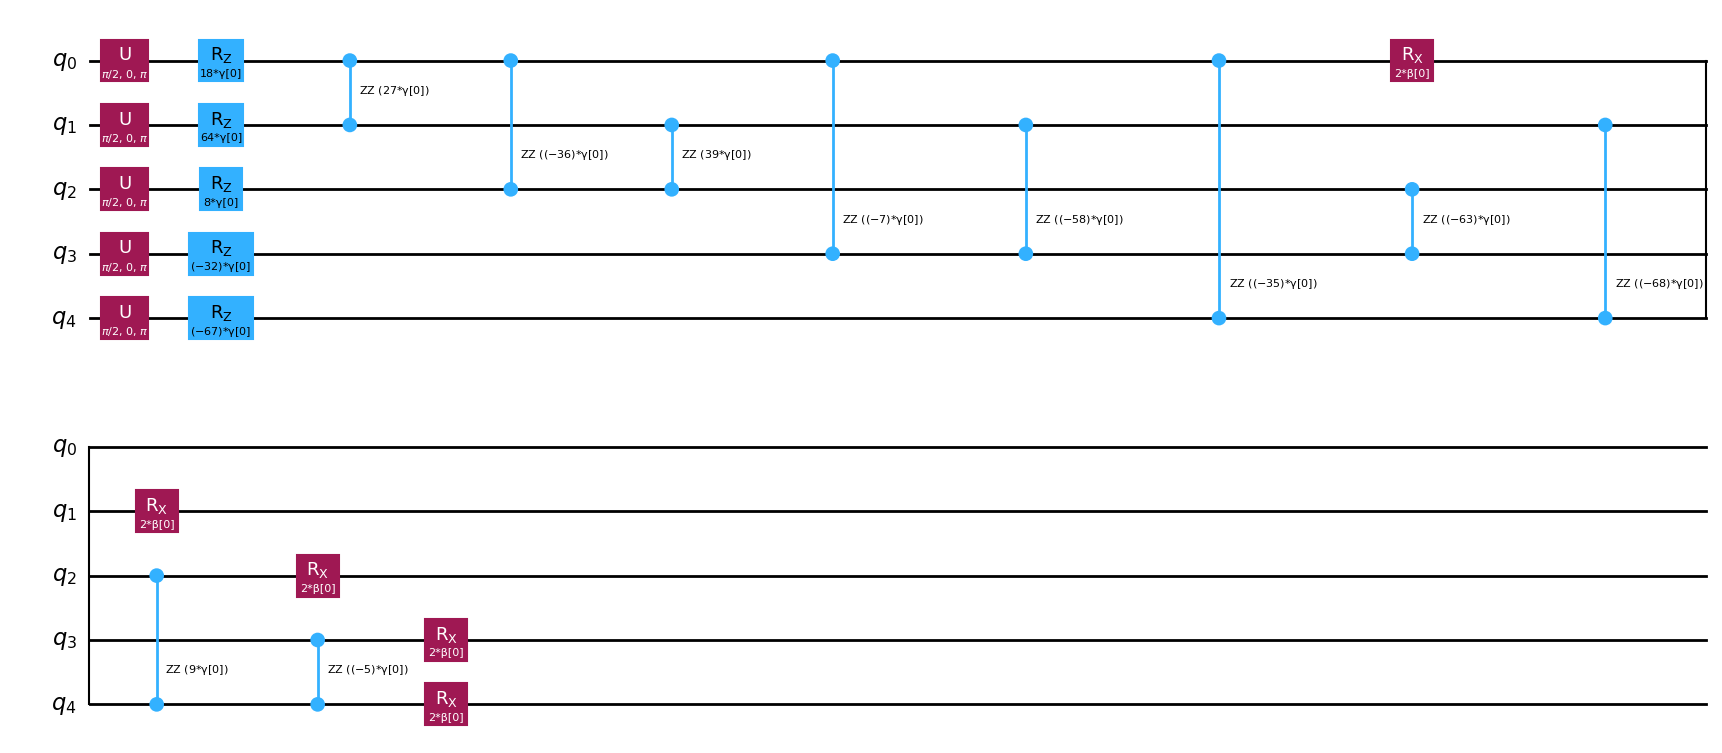

In [1154]:
circuito = QAOAAnsatz(cost_operator = Hc, reps = 1)


print(circuito.decompose(reps = 2)) 

circuito.decompose(reps = 2).draw('mpl') #Muestro el circuito

#### Prueba de StatevectorEstimator()

In [1155]:
circuito.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(γ[0])])

In [1156]:
circuito_cop = circuito.copy()
circuito_cop.measure_all()

In [1157]:
simulator = StatevectorEstimator()

x_prueba = np.random.uniform(0, 2*np.pi, circuito_cop.num_parameters)

job = simulator.run([(circuito, Hc, x_prueba)])
result = job.result()[0]

In [1158]:
print(result.data.evs)

-3.2599285393356494


### Definición del Algoritmo de QAOA

In [1159]:
def qaoa_algorithm(circuito, Hc, min_method = 'Nelder-Mead'):
    

    parameters = circuito.parameters
    #Obtengo parametros = ParameterView([Parameter(beta[]0),.., Parameter(alfa[0]),.., Parameter[alfa[n - 1]]])


    num_parameters = circuito.num_parameters

    def func_to_minimize(x):

        simulator = StatevectorEstimator() #Instancio el simulador exacto sin ruido

        job = simulator.run([(circuito, Hc, x)])
        result = job.result()[0]
        
        print(result.data.evs)
        return result.data.evs
    

    x0 = np.asarray([0.0]*num_parameters) #Parametros iniciales

    result = minimize(func_to_minimize, x0, method = min_method)

    return {param: val for param, val in zip(parameters, result.x)}

In [1160]:
opt_parameters_dict = qaoa_algorithm(circuito, Hc)

print(opt_parameters_dict)

ncircuito = circuito.assign_parameters(opt_parameters_dict) #Asigno los parametros

print(ncircuito.decompose(reps = 2)) #Muestro el circuito

-9.298117831235686e-16
1.0449974219284286e-14
-8.777700788442644e-16
-0.0027344989952748297
-0.008200897913062718
-0.002735008651936297
-0.02185921370693481
-0.049120616357590144
-0.0653790386734362
-0.12477063581245564
-0.2348075559041239
-0.4586914357457791
-0.6415493169500575
-1.1462066372315287
-1.8468863448662374
-3.1338664314221205
-4.033421416528487
-5.313950503850938
-5.6641479558967545
-3.4424915892527523
-3.527568127983889
-5.063826265931801
-4.90733978114388
-5.505991336099637
-4.706911109769427
-5.604708121949188
-5.747913982011482
-5.731096593901473
-5.823003392493206
-5.832675485094567
-6.050399679578479
-6.199086318988694
-6.238124594485569
-6.205493041223147
-6.653278103863604
-6.863185667461217
-7.176488940685371
-7.57415712426455
-8.089185222774756
-8.210730508403344
-10.002893413951169
-11.574932936934522
-9.31396587133135
-14.208718766016688
-17.0177943179254
-16.268720890208684
-23.839053098663115
-29.476415409442055
-19.182416007870597
-32.262227930515806
-33.4903

In [1161]:
def samples_from_parameters (circuit, opt_parameters, Hc, shots):

    sampler = StatevectorSampler() #Declaro un Sampler exacto

    circWithParam = circuit.assign_parameters(opt_parameters)

    circWithParam.measure_all()

    
    job = sampler.run([(circWithParam, None)], shots = shots)
    
    result = job.result()[0] 

    counts = result.data.meas.get_counts() #Obtengo un diccionario [bitstring : frecuencia]

    ordered_counts = dict(sorted(counts.items(), key = lambda x: x[1], reverse = True))

    return ordered_counts

In [1162]:
results = samples_from_parameters(circuito, opt_parameters_dict, Hc, shots = 10_000)

In [1163]:
print(len(results))
for bitstring, count in results.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

32
Bistring: 00101 -> Counts: 1043
Bistring: 00010 -> Counts: 1008
Bistring: 11111 -> Counts: 932
Bistring: 10011 -> Counts: 696
Bistring: 00000 -> Counts: 686
Bistring: 01111 -> Counts: 675
Bistring: 01110 -> Counts: 610
Bistring: 01101 -> Counts: 607
Bistring: 10010 -> Counts: 546
Bistring: 00001 -> Counts: 517
Bistring: 00100 -> Counts: 395
Bistring: 01010 -> Counts: 369
Bistring: 00011 -> Counts: 239
Bistring: 11010 -> Counts: 233
Bistring: 11011 -> Counts: 225
Bistring: 10101 -> Counts: 201
Bistring: 11110 -> Counts: 193
Bistring: 10111 -> Counts: 175
Bistring: 01100 -> Counts: 166
Bistring: 00111 -> Counts: 104
Bistring: 10001 -> Counts: 74
Bistring: 00110 -> Counts: 73
Bistring: 01011 -> Counts: 68
Bistring: 11000 -> Counts: 41
Bistring: 11001 -> Counts: 37
Bistring: 11100 -> Counts: 26
Bistring: 10000 -> Counts: 17
Bistring: 11101 -> Counts: 14
Bistring: 10110 -> Counts: 11
Bistring: 01000 -> Counts: 7
Bistring: 10100 -> Counts: 7
Bistring: 01001 -> Counts: 5


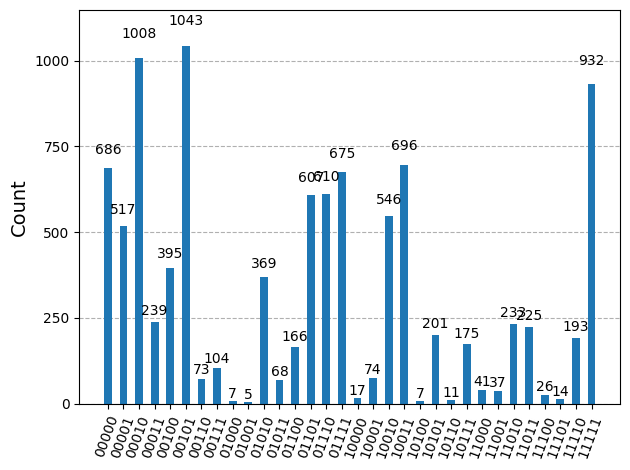

In [1164]:
plot_histogram(results)

### Obtener Pares SR

In [1165]:
def bitstring2vector(bitstrings):

    return np.array([[int(c) for c in bstring] for bstring in bitstrings])


def bitstring2latticeVectors(D, state_bistring, step_signs, b_op): 

    bits = bitstring2vector(state_bistring) #Obtengo el vector de bits de la cadena

    aux = np.multiply(step_signs, bits)

    movement = aux @ D # (n_states, n_bits) @ (n_bits, n_dim)
    

    vnew = b_op + movement

    return vnew

In [1166]:
vnew = bitstring2latticeVectors(D, results.keys(), step_signs, b_op)
print(vnew)

[[     4.     -7.     -3.     14.      5. 176974.]
 [    14.     12.      3.     -2.      0. 176984.]
 [    -8.      5.      0.      8.      3. 176979.]
 [     4.     13.     -6.     -2.      3. 176970.]
 [    12.      1.      0.     -2.      6. 176987.]
 [    -2.      1.      6.     12.      1. 176976.]
 [     2.      4.      9.      8.      0. 176993.]
 [    -4.    -10.      3.     12.      7. 176979.]
 [     8.     16.     -3.     -6.      2. 176987.]
 [     8.     -2.     -3.      2.      7. 176970.]
 [     8.     -4.      0.     10.      4. 176991.]
 [     6.      9.      9.     -4.      2. 176989.]
 [    10.      9.      0.      2.      1. 176967.]
 [     0.     13.      3.     -8.      4. 176992.]
 [    -4.     10.      0.     -4.      5. 176975.]
 [    -2.     -3.     -9.     10.      7. 176977.]
 [    -4.      8.      3.      4.      2. 176996.]
 [     0.      8.     -6.     10.      1. 176974.]
 [     0.     -7.      6.      8.      6. 176996.]
 [     6.      4.      0.     1

In [1167]:
res_vectors = np.subtract(vnew, t)

for vector in res_vectors:
    print(np.linalg.norm(vector))

20.396078054371138
18.81488772222678
14.071247279470288
21.42428528562855
13.74772708486752
16.34013463836819
15.132745950421556
18.81488772222678
19.313207915827967
18.841443681416774
15.231546211727817
15.297058540778355
22.58317958127243
17.52141546793523
16.0312195418814
17.52141546793523
15.165750888103101
17.944358444926362
17.4928556845359
21.095023109728988
17.832554500127006
16.46207763315433
15.937377450509228
16.492422502470642
15.231546211727817
17.916472867168917
14.89966442575134
17.291616465790582
14.7648230602334
13.601470508735444
13.892443989449804
14.66287829861518


In [1168]:
def is_smooth(u, smooth_bound): # Comprobar si es n_smooth
    base = primes[: smooth_bound]
    
    for p in base:
        while u % p == 0:
            u //= p
    
    return u == 1


def vectors2uv_pairs(B, vectors, n):
    first_n_primes = primes[:n]

    B_inv = np.linalg.pinv(B)

    exponentes = np.rint(vectors @ B_inv.T).astype(int) #Obtengo el vector con los exponentes

    u_exp = np.where(exponentes > 0, exponentes, 0) #Obtengo los exponentes positivos
    v_exp = np.where(exponentes < 0, -exponentes, 0) #Obtengo los exponentes negativos y les cambio de signo

    #Obtengo los valores u y v
    u = np.prod(np.power(first_n_primes, u_exp, dtype = object), axis = 1) 
    v = np.prod(np.power(first_n_primes, v_exp, dtype = object), axis = 1)
    

    return np.stack((u, v), axis = 1)

In [1169]:
uv_pairs = vectors2uv_pairs(B, vnew, n)
print(uv_pairs)

[[530529694772 10935]
 [340122240 7]
 [776562633 16]
 [8488175652 175]
 [340139712 7]
 [97060425 2]
 [48620250 1]
 [11463230904895 236196]
 [83338451856 1715]
 [2182563152 45]
 [3937140592 81]
 [2381643000 49]
 [48498912 1]
 [116712415215 2401]
 [9509900499 196]
 [327520882997 6750]
 [194500845 4]
 [1212977997 25]
 [106337949025 2187]
 [533655864 11]
 [42443058438 875]
 [5881105440 121]
 [48514950 1]
 [233436821409 4802]
 [285311670611 5880]
 [10503585169 216]
 [416713664664 8575]
 [5661432406091 116640]
 [243045684 5]
 [21435888100 441]
 [1215290846 25]
 [11789738455 243]]


In [1170]:
def uv_pairs2sr_pairs(uv_pairs, N, n):
    sr_pairs = [tuple(u_v) for u_v in uv_pairs if is_smooth(abs(int(u_v[0]) - N*int(u_v[1])), n)]

    return sr_pairs

sr_pairs = uv_pairs2sr_pairs(uv_pairs, N, smooth_bound)

print(sr_pairs)

[(11789738455, 243)]
